### **Overall Setup**

In [1]:
# 1. Install necessary libraries (if not already installed)
!pip install -q transformers kagglehub librosa scikit-learn matplotlib seaborn aubio datetime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.0/479.0 kB 14.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.9/264.9 kB 18.1 MB/s eta 0:00:00


In [2]:
import torch
import json
import pickle
from datetime import datetime
import numpy as np
import librosa
import os
import pandas as pd
import kagglehub
from tqdm.notebook import tqdm
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from aubio import source, pitch
import matplotlib.pyplot as plt
import seaborn as sns

### **MODELL AND DATA SETUP + EMBEDDINGS**

In [3]:
# --- STEP 1: LOAD MODEL & DATASET ---

# Check for GPU
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load Whisper Tiny Model (Encoder mainly)

used_model = "openai/whisper-tiny"
processor = AutoProcessor.from_pretrained(used_model)
model = AutoModelForSpeechSeq2Seq.from_pretrained(used_model)
model.to(device)
model.eval() # Set to evaluation mode

# Download Dataset
print("Downloading/Loading dataset...")
dataset_path = kagglehub.dataset_download("piyushagni5/berlin-database-of-emotional-speech-emodb")
wav_path = os.path.join(dataset_path, "wav") # EMODB audio usually sits in a 'wav' folder
print(f"Audio files location: {wav_path}")

Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

generation_config.json: 0.00B [00:00, ?B/s]

Downloading/Loading dataset...


100%|██████████| 38.0M/38.0M [00:00<00:00, 117MB/s]

Extracting files...


Audio files location: /root/.cache/kagglehub/datasets/piyushagni5/berlin-database-of-emotional-speech-emodb/versions/1/wav


In [4]:
# --- STEP 2: PREPARE DATAFRAME ---

# List files
file_list = [f for f in os.listdir(wav_path) if f.endswith('.wav')]
file_paths = []
emotions = []

# Emotion Mapping (German Code -> English Label)
emotion_map = {
    'W': 'angry', 'L': 'boredom', 'E': 'disgust', 'A': 'fear',
    'F': 'happy', 'T': 'sad', 'N': 'neutral'
}

for file in file_list:
    file_paths.append(os.path.join(wav_path, file))
    code = file[5].upper()
    emotions.append(emotion_map.get(code, 'unknown'))

emodb_df = pd.DataFrame({'Path': file_paths, 'Emotions': emotions})

def get_gender(file_path):
    # Extract speaker ID from file name (e.g., '03' from '03b10Wc.wav')
    speaker_id = file_path.split('/')[-1][0:2]
    # Map speaker ID to gender based on EMODB convention:
    if speaker_id in ['03', '10', '11', '12', '15']:
        return 'male'
    elif speaker_id in ['08', '09', '13', '14', '16']:
        return 'female'
    return 'unknown'

emodb_df['Gender'] = emodb_df['Path'].apply(get_gender)
print(emodb_df['Gender'].value_counts())

print(f"Dataset prepared: {len(emodb_df)} samples.")

Gender
female    302
male      233
Name: count, dtype: int64
Dataset prepared: 535 samples.


In [5]:
emodb_df.head()

,Path,Emotions,Gender
0,/root/.cache/kagglehub/datasets/piyushagni5/be...,sad,female
1,/root/.cache/kagglehub/datasets/piyushagni5/be...,happy,female
2,/root/.cache/kagglehub/datasets/piyushagni5/be...,sad,male
3,/root/.cache/kagglehub/datasets/piyushagni5/be...,boredom,male
4,/root/.cache/kagglehub/datasets/piyushagni5/be...,neutral,male


In [6]:
# --- STEP 3: EXTRACT WHISPER EMBEDDINGS ---

def extract_embeddings(audio_paths, processor, model, device):
    embeddings = []

    # Process files with a progress bar
    for path in tqdm(audio_paths, desc="Extracting Embeddings"):
        try:
            # 1. Load and Resample to 16kHz (Required by Whisper)
            audio, sr = librosa.load(path, sr=16000) # Das machen wir damit es wirklich 16k Herz sind.

            # 2. Preprocess: Pad/Truncate to 30 seconds, das machen wir damit jeder Input gleich ist
            inputs = processor(
                audio,
                sampling_rate=16000,
                return_tensors="pt",
                truncation=True,
                padding="max_length",
                max_length=480000 # 30s * 16000Hz
            )

            input_features = inputs.input_features.to(device)

            # 3. Pass through Encoder Only to get Embeddings [cite: 21]
            with torch.no_grad():
                encoder_outputs = model.model.encoder(input_features) # normalerweise würde man hier model.generate() machen, fürs transkribieren, aber wir neben quasi nur den halbenweg und lassen uns die embeddings geben.
                last_hidden_state = encoder_outputs.last_hidden_state # Reduktion nur auf den letzten Vektor mit den Audio-Features.

                # 4. Mean Pooling (Average over time dimension)
                # This turns the (Batch, Time, Features) sequence into a single (Features) vector
                file_embedding = last_hidden_state.mean(dim=1).squeeze().cpu().numpy() # Zusammenfassung der Emotionen in eine 3D Matrix (Batch_Size, Time_Steps, Features), dadurch haben wir eine moment für moment aufnahme, dann wird der durchschnittberechnet, und wir haben nurnoch einen Vekotr, der dann quasi die "Kernessenz" ist.

            embeddings.append(file_embedding)

        except Exception as e:
            print(f"Error with {path}: {e}")
            embeddings.append(None)

    return np.array(embeddings)

# Run extraction
X = extract_embeddings(emodb_df['Path'], processor, model, device)
y = emodb_df['Emotions'].values

# Check shapes
print(f"Features Shape: {X.shape}") # (535, 384) for tiny

Extracting Embeddings:   0%|          | 0/535 [00:00<?, ?it/s]

Features Shape: (535, 384)


### **DEFINITION OF METHODS**
+ CROSSVALIDATION
+ EVALUATION AND REPORT
+ EVALUATION GENDERBIAS
+ SAVE RESULTS

In [ ]:
def safeResults(name_dataset, name_model, y_true, y_pred, fold_accuracies):

  date = datetime.now().strftime("%Y-%m-%d")
  time = datetime.now().strftime("%H:%M:%S")

  # 1. Your data and folder setup
  results_dir = os.path.join(os.getcwd(), 'results_dir')

  # 2. Create the folder if it doesn't exist
  if not os.path.exists(results_dir):
      os.makedirs(results_dir)

  # 3. Define the file name and full path
  file_path = os.path.join(results_dir, f'results_{name_dataset}_{name_model}_{date}_{time}.json')

  results = {
      'date': date,
      'time': time,
      'name_dataset': name_dataset,
      'name_model': name_model,
      'report': classification_report(y_true, y_pred, output_dict=True)
  }

  with open(file_path, 'w') as f:
    # Use json.dump and indent for beautiful formatting
    json.dump(results, f, indent=4)

  print(f"Data successfully saved to {file_path}")

In [ ]:
# --- STEP 4: Def Cross Valdation ---
def run_cross_validation(X, y, model, num_folds=5, random_state=42):

    # Initialize StratifiedKFold
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)

    # Lists to store results
    fold_accuracies = []
    all_y_true = []
    all_y_pred = []
    all_original_indices = [] # New: To store original indices of test samples
    global clf

    print(f"Starte Training mit {skf.get_n_splits()}-Fold Cross-Validation...")

    # Loop over folds
    for fold, (train_index, test_index) in enumerate(tqdm(skf.split(X, y), total=num_folds, desc="Folds")):

      # Daten aufteilen basierend auf den Indizes des aktuellen Folds
      X_train_fold, X_test_fold = X[train_index], X[test_index]
      y_train_fold, y_test_fold = y[train_index], y[test_index]

      # Modell initialisieren ()
      if model == 'logreg':
        clf = LogisticRegression(max_iter=3000, random_state=42)
      elif model == 'mlp':
        clf = MLPClassifier (hidden_layer_sizes=(512,), max_iter=1000, random_state=42, solver='adam', activation='relu')

      # Training auf dem 80% Teil
      clf.fit(X_train_fold, y_train_fold)

      # Vorhersage auf dem 20% Teil
      y_pred_fold = clf.predict(X_test_fold)

      # Speichern der Ergebnisse für Step 5
      # Wir speichern die Genauigkeit dieses spezifischen Durchlaufs
      acc = accuracy_score(y_test_fold, y_pred_fold)
      fold_accuracies.append(acc)

      # Wir sammeln ALLE wahren Labels und ALLE Vorhersagen in einer langen Liste
      # Das ermöglicht uns später eine Confusion Matrix über den gesamten Datensatz
      all_y_true.extend(y_test_fold)
      all_y_pred.extend(y_pred_fold)
      all_original_indices.extend(test_index) # New: Store original indices

    return all_y_true, all_y_pred, fold_accuracies, all_original_indices # New: Return indices

    print(f"Fold {fold+1} Accuracy: {acc*100:.2f}%")

    print("\nTraining abgeschlossen. Ergebnisse sind gespeichert für Step 5, basierend auf dem gegebenen Modell.")


In [ ]:
# --- STEP 5: DEF EVALUATION & REPORT ---

def evaluate_and_report(all_y_true, all_y_pred, fold_accuracies):
  # 1. Durchschnittliche Genauigkeit berechnen
  mean_acc = np.mean(fold_accuracies)
  std_acc = np.std(fold_accuracies)

  print(f"\n{'='*40}")
  print(f"GESAMTERGEBNIS (5-FOLD CV)")
  print(f"{'='*40}")
  print(f"Durchschnittliche Accuracy: {mean_acc*100:.2f}%")
  print(f"Standardabweichung:         +/- {std_acc*100:.2f}%")
  print(f"{'='*40}\n")

  # 2. Detaillierter Klassifikationsreport
  # Hier nutzen wir die gesammelten Vorhersagen aller Folds
  print("Detaillierter Bericht pro Emotion:")
  print(classification_report(all_y_true, all_y_pred))

  # 3. Confusion Matrix Visualisierung
  # Wir erstellen die Matrix basierend auf allen gesammelten Daten
  cm = confusion_matrix(all_y_true, all_y_pred)

  # Hole die Klassennamen aus dem letzten trainierten Modell für die Beschriftung
  class_names = clf.classes_

  plt.figure(figsize=(10, 8))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
  plt.title(f'Confusion Matrix (Aggregiert über 5 Folds)')
  plt.ylabel('Wahre Emotion')
  plt.xlabel('Vorhergesagte Emotion')
  plt.show()

In [ ]:
def evaluate_gender_bias(all_y_true, all_y_pred, all_original_indices, emodb_df, model_name):
    print(f"\n{'='*20} Gender Bias Analysis for {model_name} {'='*20}")

    # Create a temporary DataFrame to link predictions with original data and gender
    results_df = pd.DataFrame({
        'original_index': all_original_indices,
        'true_emotion': all_y_true,
        'predicted_emotion': all_y_pred
    })

    # Merge with emodb_df to get gender information
    emodb_df_temp = emodb_df.copy()
    emodb_df_temp['original_index'] = emodb_df_temp.index # Add current index as a column for merging
    merged_results = pd.merge(results_df, emodb_df_temp[['original_index', 'Gender']], on='original_index', how='left')

    class_names = np.unique(all_y_true) # Get all unique classes from the overall true labels for consistent CM labels

    # Evaluate for Male actors
    male_results = merged_results[merged_results['Gender'] == 'male']
    if not male_results.empty:
        male_accuracy = accuracy_score(male_results['true_emotion'], male_results['predicted_emotion'])
        print(f"\n--- {model_name}: Male Voice Actors ---")
        print(f"Accuracy: {male_accuracy*100:.2f}%")
        print("\nDetaillierter Bericht pro Emotion (Male):")
        print(classification_report(male_results['true_emotion'], male_results['predicted_emotion'], labels=class_names, zero_division=0))


    else:
        print(f"\nNo male samples found for {model_name} evaluation.")

    # Evaluate for Female actors
    female_results = merged_results[merged_results['Gender'] == 'female']
    if not female_results.empty:
        female_accuracy = accuracy_score(female_results['true_emotion'], female_results['predicted_emotion'])
        print(f"\n--- {model_name}: Female Voice Actors ---")
        print(f"Accuracy: {female_accuracy*100:.2f}%")
        print("\nDetaillierter Bericht pro Emotion (Female):")
        print(classification_report(female_results['true_emotion'], female_results['predicted_emotion'], labels=class_names, zero_division=0))

    else:
        print(f"\nNo female samples found for {model_name} evaluation.")

    # Compare the accuracy, precision, etc.

    print(f"\n{'='*20} Accuracy Comparison {'='*20}")
    print(f"Accuracy for {model_name} on Male Voice Actors: {male_accuracy*100:.2f}%")
    print(f"Accuracy for {model_name} on Female Voice Actors: {female_accuracy*100:.2f}%")

**Comparison Methode**


In [ ]:
# Simple method, which compares the results of different evaluations
# def simple_comparison()

### USAGE OF THE METHODS

**Overall Check with two models and cross-validation**

Logistic Regression:
Starte Training mit 5-Fold Cross-Validation...


Folds:   0%|          | 0/5 [00:00<?, ?it/s]


GESAMTERGEBNIS (5-FOLD CV)
Durchschnittliche Accuracy: 80.75%
Standardabweichung:         +/- 2.33%

Detaillierter Bericht pro Emotion:
              precision    recall  f1-score   support

       angry       0.77      0.95      0.85       127
     boredom       0.86      0.86      0.86        81
     disgust       0.82      0.67      0.74        46
        fear       0.83      0.72      0.78        69
       happy       0.70      0.49      0.58        71
     neutral       0.78      0.87      0.82        79
         sad       0.95      0.90      0.93        62

    accuracy                           0.81       535
   macro avg       0.81      0.78      0.79       535
weighted avg       0.81      0.81      0.80       535



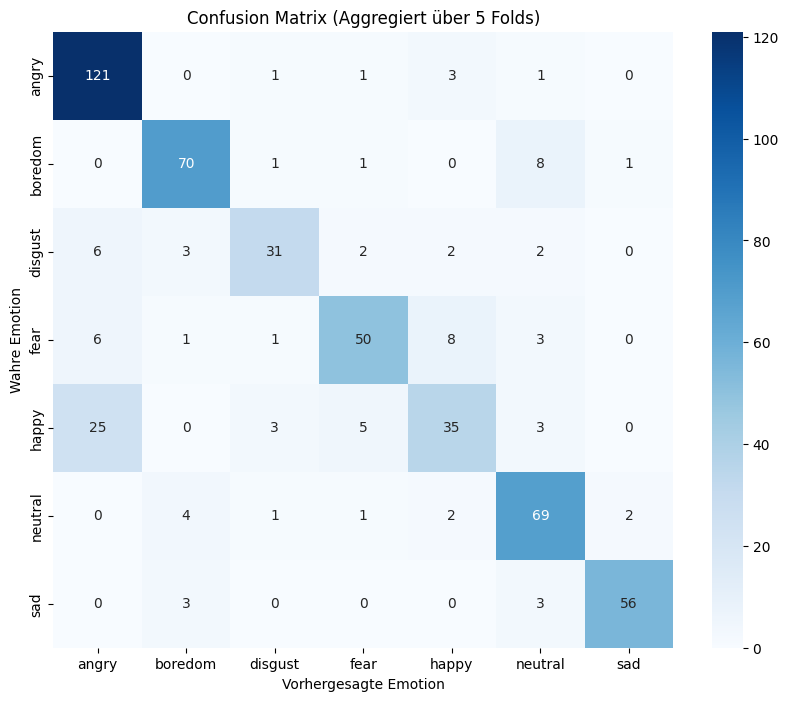

Data successfully saved to /content/results_dir/results_emoDB_logreg_2026-02-06_14:29:43.json
MLP:
Starte Training mit 5-Fold Cross-Validation...


Folds:   0%|          | 0/5 [00:00<?, ?it/s]


GESAMTERGEBNIS (5-FOLD CV)
Durchschnittliche Accuracy: 83.55%
Standardabweichung:         +/- 3.99%

Detaillierter Bericht pro Emotion:
              precision    recall  f1-score   support

       angry       0.77      0.93      0.84       127
     boredom       0.91      0.86      0.89        81
     disgust       0.88      0.83      0.85        46
        fear       0.83      0.75      0.79        69
       happy       0.77      0.56      0.65        71
     neutral       0.84      0.91      0.87        79
         sad       0.93      0.92      0.93        62

    accuracy                           0.84       535
   macro avg       0.85      0.82      0.83       535
weighted avg       0.84      0.84      0.83       535



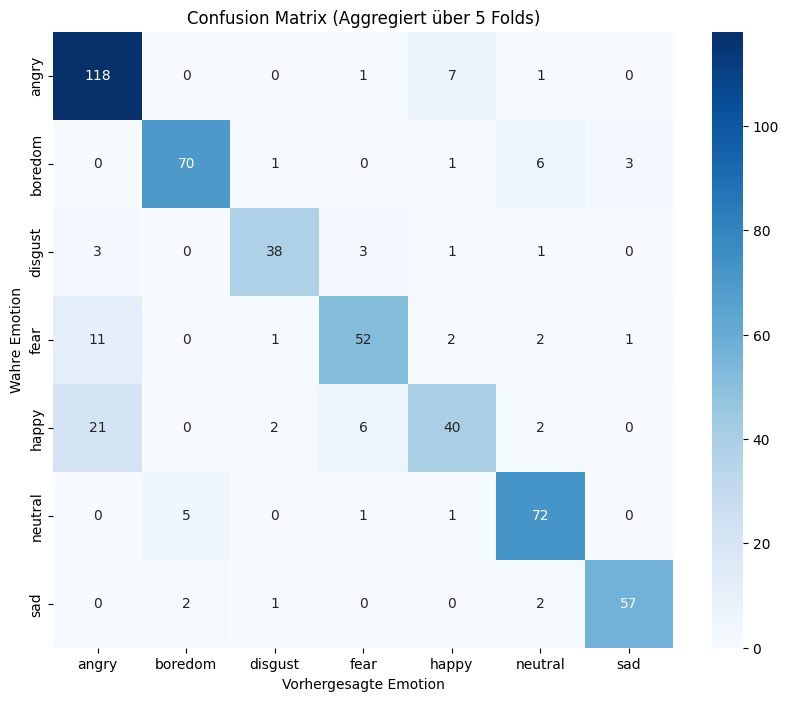

Data successfully saved to /content/results_dir/results_emoDB_mlp_2026-02-06_14:30:16.json


In [ ]:
print("Logistic Regression:")
y_true, y_pred, fold_accuracies, original_indices_lr= run_cross_validation(X, y, model  = 'logreg')
evaluate_and_report(y_true, y_pred, fold_accuracies)
safeResults('emoDB', 'logreg', y_true, y_pred, fold_accuracies)

print("MLP:")
y_true, y_pred, fold_accuracies, original_indices_lr = run_cross_validation(X, y, model  = 'mlp')
evaluate_and_report(y_true, y_pred, fold_accuracies)
safeResults('emoDB', 'mlp', y_true, y_pred, fold_accuracies)


**CHECK ON GENDER-BIAS**


In [ ]:
print("Logistic Regression:")
y_true_lr, y_pred_lr, fold_accuracies_lr, original_indices_lr = run_cross_validation(X, y, model  = 'logreg')
evaluate_gender_bias(y_true_lr, y_pred_lr, original_indices_lr, emodb_df, 'logreg')

print("MLP:")
y_true_mlp, y_pred_mlp, fold_accuracies_mlp, original_indices_mlp = run_cross_validation(X, y, model  = 'mlp')
evaluate_gender_bias(y_true_mlp, y_pred_mlp, original_indices_mlp, emodb_df, 'mlp')

Logistic Regression:
Starte Training mit 5-Fold Cross-Validation...


Folds:   0%|          | 0/5 [00:00<?, ?it/s]


==================== Gender Bias Analysis for logreg ====================

--- logreg: Male Voice Actors ---
Accuracy: 79.83%

Detaillierter Bericht pro Emotion (Male):
              precision    recall  f1-score   support

       angry       0.78      0.95      0.86        60
     boredom       0.84      0.89      0.86        35
     disgust       0.71      0.45      0.56        11
        fear       0.84      0.72      0.78        36
       happy       0.67      0.37      0.48        27
     neutral       0.76      0.90      0.82        39
         sad       0.92      0.88      0.90        25

    accuracy                           0.80       233
   macro avg       0.79      0.74      0.75       233
weighted avg       0.79      0.80      0.79       233


--- logreg: Female Voice Actors ---
Accuracy: 81.46%

Detaillierter Bericht pro Emotion (Female):
              precision    recall  f1-score   support

       angry       0.75      0.96      0.84        67
     boredom       0.89  

Folds:   0%|          | 0/5 [00:00<?, ?it/s]


==================== Gender Bias Analysis for mlp ====================

--- mlp: Male Voice Actors ---
Accuracy: 81.97%

Detaillierter Bericht pro Emotion (Male):
              precision    recall  f1-score   support

       angry       0.81      0.95      0.88        60
     boredom       0.86      0.86      0.86        35
     disgust       0.88      0.64      0.74        11
        fear       0.77      0.75      0.76        36
       happy       0.87      0.48      0.62        27
     neutral       0.77      0.87      0.82        39
         sad       0.88      0.92      0.90        25

    accuracy                           0.82       233
   macro avg       0.83      0.78      0.80       233
weighted avg       0.82      0.82      0.81       233


--- mlp: Female Voice Actors ---
Accuracy: 84.77%

Detaillierter Bericht pro Emotion (Female):
              precision    recall  f1-score   support

       angry       0.73      0.91      0.81        67
     boredom       0.95      0.87 

**CHECK ON GENDER-BIAS IF TRAINING JUST ON GENDER**

Extracting Embeddings:   0%|          | 0/233 [00:00<?, ?it/s]

Extracting Embeddings:   0%|          | 0/302 [00:00<?, ?it/s]

Logistic Regression, male:
Starte Training mit 5-Fold Cross-Validation...


Folds:   0%|          | 0/5 [00:00<?, ?it/s]


GESAMTERGEBNIS (5-FOLD CV)
Durchschnittliche Accuracy: 72.11%
Standardabweichung:         +/- 4.21%

Detaillierter Bericht pro Emotion:
              precision    recall  f1-score   support

       angry       0.75      0.95      0.84        60
     boredom       0.68      0.77      0.72        35
     disgust       0.00      0.00      0.00        11
        fear       0.68      0.69      0.68        36
       happy       0.53      0.30      0.38        27
     neutral       0.76      0.79      0.78        39
         sad       0.87      0.80      0.83        25

    accuracy                           0.72       233
   macro avg       0.61      0.62      0.60       233
weighted avg       0.68      0.72      0.69       233



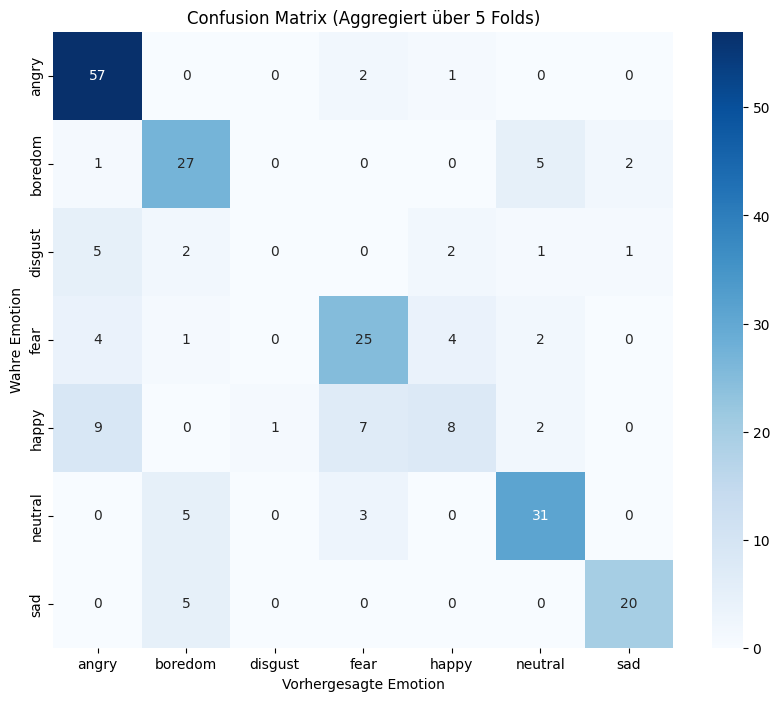

Data successfully saved to /content/results_dir/results_Male_emoDB_logReg_2026-02-06_14:36:57.json
Logistic Regression, female:
Starte Training mit 5-Fold Cross-Validation...


Folds:   0%|          | 0/5 [00:00<?, ?it/s]


GESAMTERGEBNIS (5-FOLD CV)
Durchschnittliche Accuracy: 78.80%
Standardabweichung:         +/- 5.83%

Detaillierter Bericht pro Emotion:
              precision    recall  f1-score   support

       angry       0.69      0.87      0.77        67
     boredom       0.85      0.87      0.86        46
     disgust       0.93      0.80      0.86        35
        fear       0.76      0.76      0.76        33
       happy       0.64      0.41      0.50        44
     neutral       0.82      0.90      0.86        40
         sad       0.92      0.89      0.90        37

    accuracy                           0.79       302
   macro avg       0.80      0.78      0.79       302
weighted avg       0.79      0.79      0.78       302



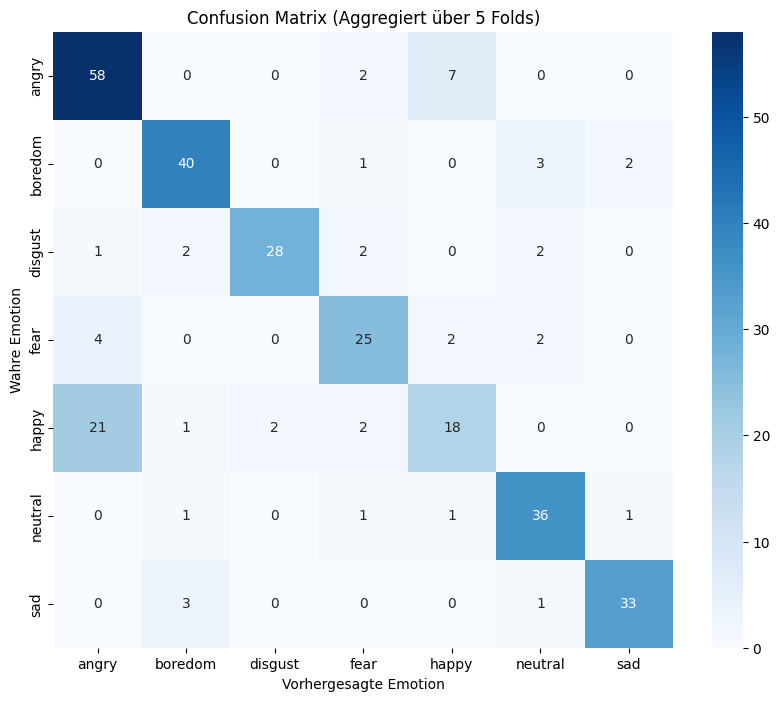

Data successfully saved to /content/results_dir/results_Female_emoDB_logReg_2026-02-06_14:37:11.json
MLP, male:
Starte Training mit 5-Fold Cross-Validation...


Folds:   0%|          | 0/5 [00:00<?, ?it/s]


GESAMTERGEBNIS (5-FOLD CV)
Durchschnittliche Accuracy: 78.58%
Standardabweichung:         +/- 8.19%

Detaillierter Bericht pro Emotion:
              precision    recall  f1-score   support

       angry       0.87      0.92      0.89        60
     boredom       0.79      0.74      0.76        35
     disgust       0.57      0.36      0.44        11
        fear       0.72      0.81      0.76        36
       happy       0.60      0.56      0.58        27
     neutral       0.83      0.87      0.85        39
         sad       0.83      0.80      0.82        25

    accuracy                           0.79       233
   macro avg       0.75      0.72      0.73       233
weighted avg       0.78      0.79      0.78       233



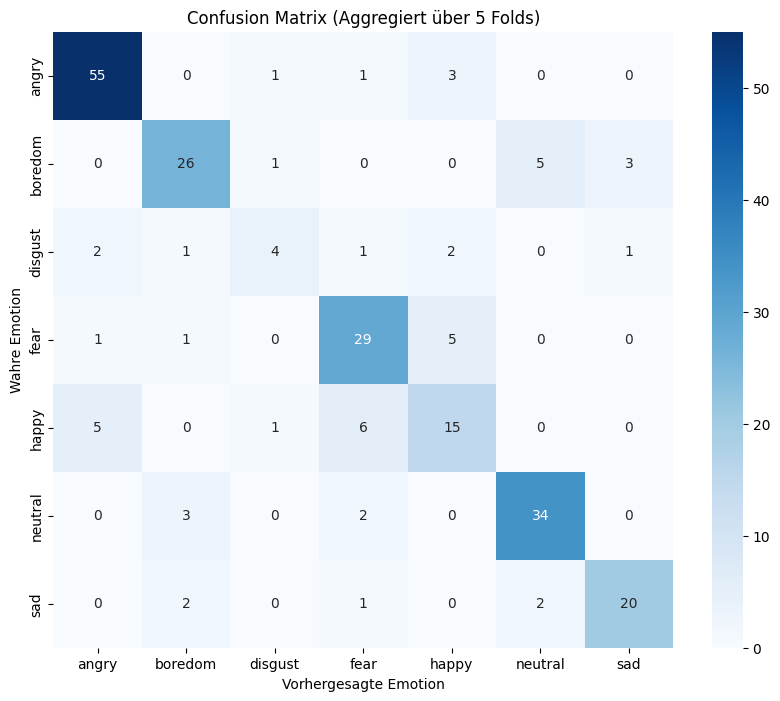

Data successfully saved to /content/results_dir/results_Male_emoDB_mlp_2026-02-06_14:37:32.json
MLP, female:
Starte Training mit 5-Fold Cross-Validation...


Folds:   0%|          | 0/5 [00:00<?, ?it/s]


GESAMTERGEBNIS (5-FOLD CV)
Durchschnittliche Accuracy: 84.09%
Standardabweichung:         +/- 5.82%

Detaillierter Bericht pro Emotion:
              precision    recall  f1-score   support

       angry       0.80      0.82      0.81        67
     boredom       0.86      0.91      0.88        46
     disgust       0.94      0.89      0.91        35
        fear       0.78      0.85      0.81        33
       happy       0.73      0.61      0.67        44
     neutral       0.86      0.93      0.89        40
         sad       0.97      0.92      0.94        37

    accuracy                           0.84       302
   macro avg       0.85      0.85      0.85       302
weighted avg       0.84      0.84      0.84       302



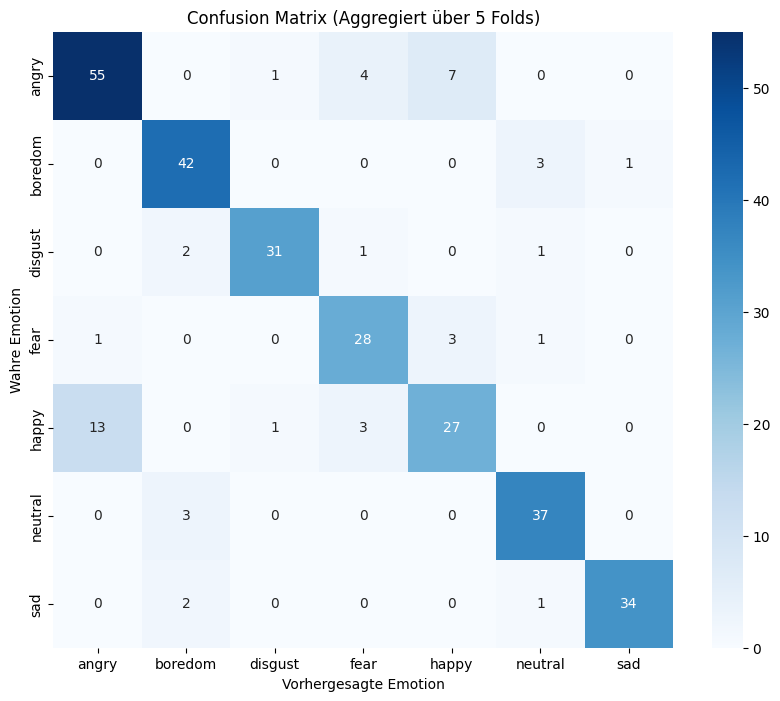

Data successfully saved to /content/results_dir/results_Female_emoDB_mlp_2026-02-06_14:37:58.json


In [ ]:
emodb_df_male = emodb_df[emodb_df['Gender'] == 'male']
emodb_df_female = emodb_df[emodb_df['Gender'] == 'female']

XMale = extract_embeddings(emodb_df_male['Path'], processor, model, device)
YMale = emodb_df_male['Emotions'].values

XFemale = extract_embeddings(emodb_df_female['Path'], processor, model, device)
YFemale = emodb_df_female['Emotions'].values

print("Logistic Regression, male:")
y_true_m_lr, y_pred_m_lr, fold_accuracies_m_lr, original_indices_m_lr = run_cross_validation(XMale, YMale, model  = 'logreg')
evaluate_and_report(y_true_m_lr, y_pred_m_lr, fold_accuracies_m_lr)
safeResults('Male_emoDB', 'logReg', y_true_m_lr, y_pred_m_lr, fold_accuracies_m_lr)

print("Logistic Regression, female:")
y_true_f_lr, y_pred_f_lr, fold_accuracies_f_lr, original_indices_f_lr = run_cross_validation(XFemale, YFemale, model  = 'logreg')
evaluate_and_report(y_true_f_lr, y_pred_f_lr, fold_accuracies_f_lr)
safeResults('Female_emoDB', 'logReg', y_true_f_lr, y_pred_f_lr, fold_accuracies_f_lr)

print("MLP, male:")
y_true_m_mlp, y_pred_m_mlp, fold_accuracies_m_mlp, original_indices_m_mlp = run_cross_validation(XMale, YMale, model  = 'mlp')
evaluate_and_report(y_true_m_mlp, y_pred_m_mlp, fold_accuracies_m_mlp)
safeResults('Male_emoDB', 'mlp', y_true_m_mlp, y_pred_m_mlp, fold_accuracies_m_mlp)

print("MLP, female:")
y_true_f_mlp, y_pred_f_mlp, fold_accuracies_f_mlp, original_indices_f_mlp = run_cross_validation(XFemale, YFemale, model  = 'mlp')
evaluate_and_report(y_true_f_mlp, y_pred_f_mlp, fold_accuracies_f_mlp)
safeResults('Female_emoDB', 'mlp', y_true_f_mlp, y_pred_f_mlp, fold_accuracies_f_mlp)



### **BACKUP + TRASH**

In [ ]:
# --- ALTERNATIV (CROSS-VALIDATION) --- STEP 4: 5-FOLD CROSS-VALIDATION TRAINING MLP ---
# 1. Setup für 5-Fold Cross-Validation
# shuffle=True sorgt für eine zufällige Durchmischung vor dem Split
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Listen zum Speichern der Ergebnisse aus jedem Durchlauf
fold_accuracies = []
all_y_true = []
all_y_pred = []

print(f"Starte Training mit {skf.get_n_splits()}-Fold Cross-Validation...")

# 2. Die Schleife über die 5 Folds
# enumerate gibt uns den Index (0 bis 4) und die Trainings-/Test-Indizes
for fold, (train_index, test_index) in enumerate(tqdm(skf.split(X, y), total=5, desc="Folds")):

    # Daten aufteilen basierend auf den Indizes des aktuellen Folds
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # Modell initialisieren (Logistic Regression, wie im Paper empfohlen)
    clf = MLPClassifier (hidden_layer_sizes=(512,), max_iter=1000, random_state=42, solver='adam', activation='relu')

    # Training auf dem 80% Teil
    clf.fit(X_train_fold, y_train_fold)

    # Vorhersage auf dem 20% Teil
    y_pred_fold = clf.predict(X_test_fold)

    # Speichern der Ergebnisse für Step 5
    # Wir speichern die Genauigkeit dieses spezifischen Durchlaufs
    acc = accuracy_score(y_test_fold, y_pred_fold)
    fold_accuracies.append(acc)

    # Wir sammeln ALLE wahren Labels und ALLE Vorhersagen in einer langen Liste
    # Das ermöglicht uns später eine Confusion Matrix über den gesamten Datensatz
    all_y_true.extend(y_test_fold)
    all_y_pred.extend(y_pred_fold)

    print(f"Fold {fold+1} Accuracy: {acc*100:.2f}%")

print("\nTraining abgeschlossen. Ergebnisse sind gespeichert für Step 5.")

In [ ]:
# --- ALTERNATIV (CROSS-VALIDATION) --- STEP 4: 5-FOLD CROSS-VALIDATION TRAINING LogR ---
# 1. Setup für 5-Fold Cross-Validation
# shuffle=True sorgt für eine zufällige Durchmischung vor dem Split
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Listen zum Speichern der Ergebnisse aus jedem Durchlauf
fold_accuracies = []
all_y_true = []
all_y_pred = []

print(f"Starte Training mit {skf.get_n_splits()}-Fold Cross-Validation...")

# 2. Die Schleife über die 5 Folds
# enumerate gibt uns den Index (0 bis 4) und die Trainings-/Test-Indizes
for fold, (train_index, test_index) in enumerate(tqdm(skf.split(X, y), total=5, desc="Folds")):

    # Daten aufteilen basierend auf den Indizes des aktuellen Folds
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # Modell initialisieren (Logistic Regression, wie im Paper empfohlen)
    clf = LogisticRegression(max_iter=3000, random_state=42)

    # Training auf dem 80% Teil
    clf.fit(X_train_fold, y_train_fold)

    # Vorhersage auf dem 20% Teil
    y_pred_fold = clf.predict(X_test_fold)

    # Speichern der Ergebnisse für Step 5
    # Wir speichern die Genauigkeit dieses spezifischen Durchlaufs
    acc = accuracy_score(y_test_fold, y_pred_fold)
    fold_accuracies.append(acc)

    # Wir sammeln ALLE wahren Labels und ALLE Vorhersagen in einer langen Liste
    # Das ermöglicht uns später eine Confusion Matrix über den gesamten Datensatz
    all_y_true.extend(y_test_fold)
    all_y_pred.extend(y_pred_fold)

    print(f"Fold {fold+1} Accuracy: {acc*100:.2f}%")

print("\nTraining abgeschlossen. Ergebnisse sind gespeichert für Step 5.")

In [ ]:
# --- STEP 5: DEF EVALUATION & REPORT ---

def evaluate_and_report(all_y_true, all_y_pred, fold_accuracies):
  # 1. Durchschnittliche Genauigkeit berechnen
  mean_acc = np.mean(fold_accuracies)
  std_acc = np.std(fold_accuracies)

  print(f"\n{'='*40}")
  print(f"GESAMTERGEBNIS (5-FOLD CV)")
  print(f"{'='*40}")
  print(f"Durchschnittliche Accuracy: {mean_acc*100:.2f}%")
  print(f"Standardabweichung:         +/- {std_acc*100:.2f}%")
  print(f"{'='*40}\n")

  # 2. Detaillierter Klassifikationsreport
  # Hier nutzen wir die gesammelten Vorhersagen aller Folds
  print("Detaillierter Bericht pro Emotion:")
  print(classification_report(all_y_true, all_y_pred))

  # 3. Confusion Matrix Visualisierung
  # Wir erstellen die Matrix basierend auf allen gesammelten Daten
  cm = confusion_matrix(all_y_true, all_y_pred)

  # Hole die Klassennamen aus dem letzten trainierten Modell für die Beschriftung
  class_names = clf.classes_

  plt.figure(figsize=(10, 8))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
  plt.title(f'Confusion Matrix (Aggregiert über 5 Folds)')
  plt.ylabel('Wahre Emotion')
  plt.xlabel('Vorhergesagte Emotion')
  plt.show()

In [ ]:
# --- ALTERNATIV (CROSS-VALIDATION) --- STEP 5: EVALUATION & REPORT ---

# 1. Durchschnittliche Genauigkeit berechnen
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print(f"\n{'='*40}")
print(f"GESAMTERGEBNIS (5-FOLD CV)")
print(f"{'='*40}")
print(f"Durchschnittliche Accuracy: {mean_acc*100:.2f}%")
print(f"Standardabweichung:         +/- {std_acc*100:.2f}%")
print(f"{'='*40}\n")

# 2. Detaillierter Klassifikationsreport
# Hier nutzen wir die gesammelten Vorhersagen aller Folds
print("Detaillierter Bericht pro Emotion:")
print(classification_report(all_y_true, all_y_pred))

# 3. Confusion Matrix Visualisierung
# Wir erstellen die Matrix basierend auf allen gesammelten Daten
cm = confusion_matrix(all_y_true, all_y_pred)

# Hole die Klassennamen aus dem letzten trainierten Modell für die Beschriftung
class_names = clf.classes_

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix (Aggregiert über 5 Folds)')
plt.ylabel('Wahre Emotion')
plt.xlabel('Vorhergesagte Emotion')
plt.show()